In [ ]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from option import Option
from pricing_methods.black_scholes_analytic import analytic_bs_pricer
from pricing_methods.binomial import binomial_pricer
from pricing_methods.monte_carlo import mc_pricer
from pricing_methods.finite_difference import fd_pricer
from pricing_methods.pinn import pinn_pricer

In [ ]:
def convergence(conv_price_fn, option, n_values):
    exact = analytic_bs_pricer(option)
    return np.array([conv_price_fn(option, n) - exact for n in n_values])

In [145]:
def self_convergence(conv_price_fn, option, n_values):
    prices = np.array([conv_price_fn(option, n) for n in n_values])
    diffs = np.abs(np.diff(prices))
    return diffs, np.log2(diffs[:-1] / diffs[1:])

In [128]:
def observed_order(n_values, errors):
    n_values, errors = np.asarray(n_values, float), np.abs(errors)

    return np.log(errors[:-1] / errors[1:]) / np.log(n_values[1:] / n_values[:-1])

In [129]:
conv_fd_fn = lambda option, n: fd_pricer(option, n_space=n, n_steps=n)
conv_bin_fn = lambda option, n: binomial_pricer(option, n_steps=n)

In [130]:
def plot_convergence(ax, n_values, errors, label, marker="o-"):
    ax.loglog(n_values, np.abs(errors), marker, label=label)

In [131]:
def add_slope(ax, n_values, init_error, p):
    n_values = np.asarray(n_values, float)
    ax.loglog(n_values, init_error * (n_values[0] / n_values) ** p, "k--", lw=0.8, label=f"order {p}")

European

In [132]:
S0 = 100.0
K = 100.0
sigma = 0.1
r = 0.07
div_yield = 0.03
T = 1.0
option_type = "call"

In [133]:
option = Option(S0, K, T, r, sigma, div_yield, option_type, "european")

In [134]:
n_values = [50 * 2 ** i for i in range(5)]

[2.21003367 2.14573903 2.02716497 2.00646998]


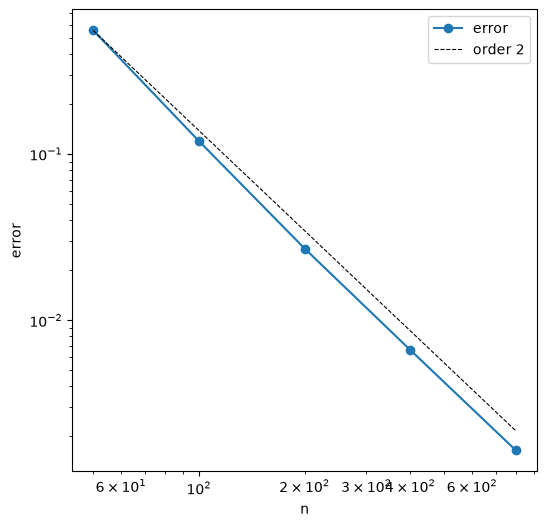

In [135]:
fig, ax = plt.subplots(figsize=(6, 6))

errors = convergence(conv_fd_fn, option, n_values)
print(observed_order(n_values, errors))
plot_convergence(ax, n_values, errors, label="error")
add_slope(ax, n_values, errors[0], 2)
ax.set_xlabel("n")
ax.set_ylabel("error")
ax.legend()
plt.show()

[0.99943075 0.99974434 0.99987943 0.99994153]


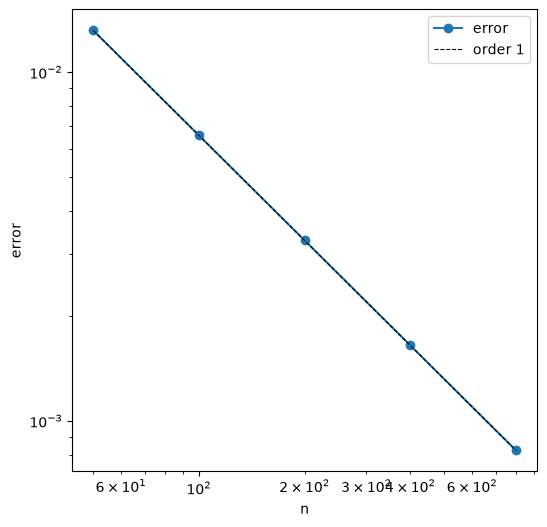

In [136]:
fig, ax = plt.subplots(figsize=(6, 6))

errors = convergence(conv_bin_fn, option, n_values)
print(observed_order(n_values, errors))
plot_convergence(ax, n_values, errors, label="error")
add_slope(ax, n_values, errors[0], 1)
ax.set_xlabel("n")
ax.set_ylabel("error")
ax.legend()
plt.show()

In [137]:
def mc_convergence(option, n_paths_values, n_reps=20, n_steps=50):
    exact = analytic_bs_pricer(option)
    rmse = []
    for n in n_paths_values:
        errs = [mc_pricer(option, n_paths=n, n_steps=n_steps, rng=s) - exact
                for s in range(n_reps)]
        rmse.append(np.sqrt(np.mean(np.square(errs))))
    return np.array(rmse)

In [138]:
n_paths_values = [50 * 2 ** i for i in range(1, 11)]

[0.43740727 0.47569346 0.5148206  0.59715756 0.47976234 0.45072139
 0.53895198 0.5510141  0.36248565]


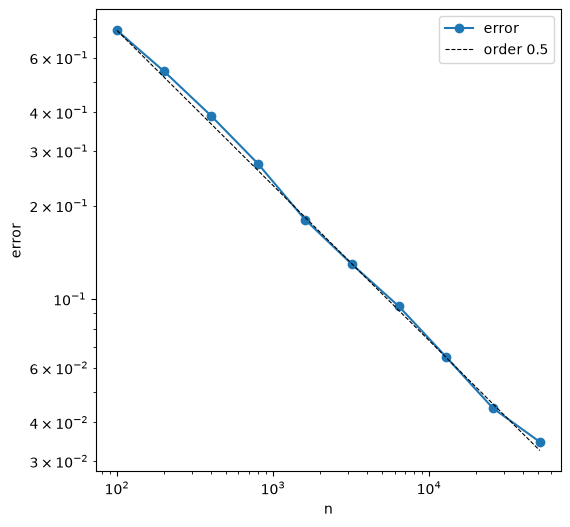

In [139]:
fig, ax = plt.subplots(figsize=(6, 6))

errors = mc_convergence(option, n_paths_values, n_reps=200)
print(observed_order(n_paths_values, errors))
plot_convergence(ax, n_paths_values, errors, label="error")
add_slope(ax, n_paths_values, errors[0], 0.5)
ax.set_xlabel("n")
ax.set_ylabel("error")
ax.legend()
plt.show()

American

In [161]:
S0 = 100.0
K = 100.0
sigma = 0.1
r = 0.07
div_yield = 0.03
T = 1.0
option_type = "put"

In [162]:
option = Option(S0, K, T, r, sigma, div_yield, option_type, "american")

In [163]:
n_values = [50 * 2 ** i for i in range(6)]

[2.49116928 1.70447157 2.27843135 1.9195346 ]


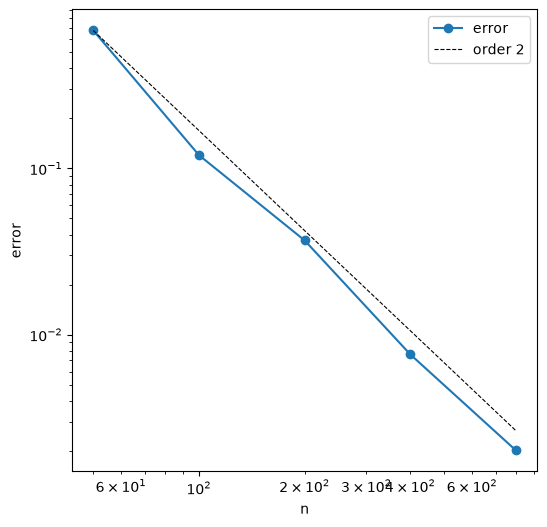

In [164]:
fig, ax = plt.subplots(figsize=(6, 6))

errors, observed_ord = self_convergence(conv_fd_fn, option, n_values)
print(observed_ord)
plot_convergence(ax, n_values[:-1], errors, label="error")
add_slope(ax, n_values[:-1], errors[0], 2)
ax.set_xlabel("n")
ax.set_ylabel("error")
ax.legend()
plt.show()

In [168]:
n_values = [10 * 2 ** i for i in range(11)]

[ 0.40590244  4.59169743  2.7895631   1.70357557 -2.08023238  0.82260127
  3.59114418  0.16521416  5.25028756]


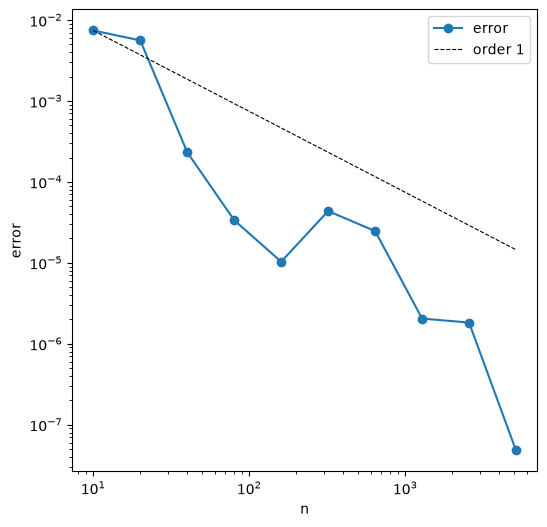

In [169]:
fig, ax = plt.subplots(figsize=(6, 6))

errors, observed_ord = self_convergence(conv_bin_fn, option, n_values)
print(observed_ord)
plot_convergence(ax, n_values[:-1], errors, label="error")
add_slope(ax, n_values[:-1], errors[0], 1)
ax.set_xlabel("n")
ax.set_ylabel("error")
ax.legend()
plt.show()